Defining Libraries

In [11]:
import os
import cv2
import albumentations as A
import matplotlib.pyplot as plt

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Defining Required Paths

In [5]:
train_dir = "/content/drive/MyDrive/DatasetForFaceMaskDetection/FaceMaskDataset/Train"

Loading Images

In [6]:
with_mask_dir = os.path.join(train_dir, "WithMask")
without_mask_dir = os.path.join(train_dir, "WithoutMask")

with_mask_images = os.listdir(with_mask_dir)
without_mask_images = os.listdir(without_mask_dir)

Displaying Sample Of Images(With And Without Mask) And Applying Augmentations Pipeline

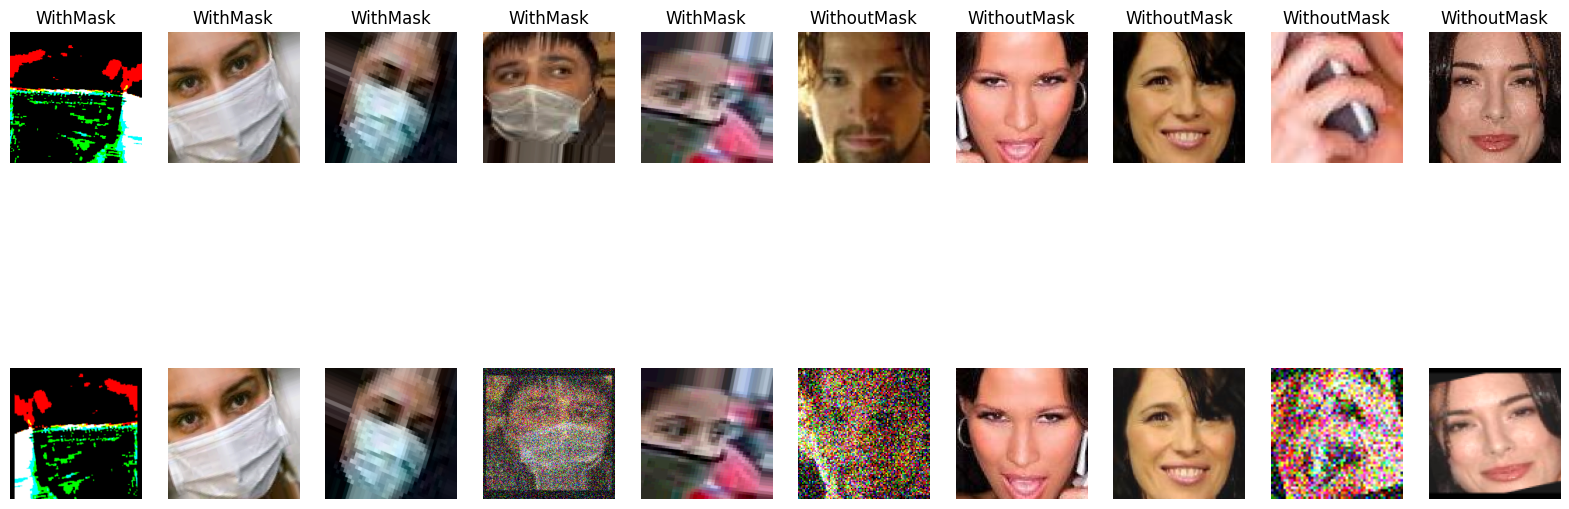

In [16]:
with_mask_dir = os.path.join(train_dir, "WithMask")
without_mask_dir = os.path.join(train_dir, "WithoutMask")

#Augmentation Pipeline
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.Affine(scale=(0.8, 1.2), p=0.5),
    A.GaussNoise(p=0.3),
])


def read_img(path):
    img = cv2.imread(path)
    if img is None:
        print("Problem In Photo: ", path)
        return None

    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img


with_images = os.listdir(with_mask_dir)[:5]
without_images = os.listdir(without_mask_dir)[:5]

all_images = [(with_mask_dir, img, "WithMask") for img in with_images] + \
             [(without_mask_dir, img, "WithoutMask") for img in without_images]


plt.figure(figsize=(20,8))

for i, (folder, img_name, label) in enumerate(all_images):
    path = os.path.join(folder, img_name)
    img = read_img(path)

    if img is None:
        continue

    # augmentation
    aug_img = transform(image=img)["image"]

    # Original
    plt.subplot(2,10,i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

    # After augmentation
    plt.subplot(2,10,i+11)
    plt.imshow(aug_img)
    plt.axis("off")

plt.show()

Different Augementions On The Same Photo (5 For Each Class As A Sample)

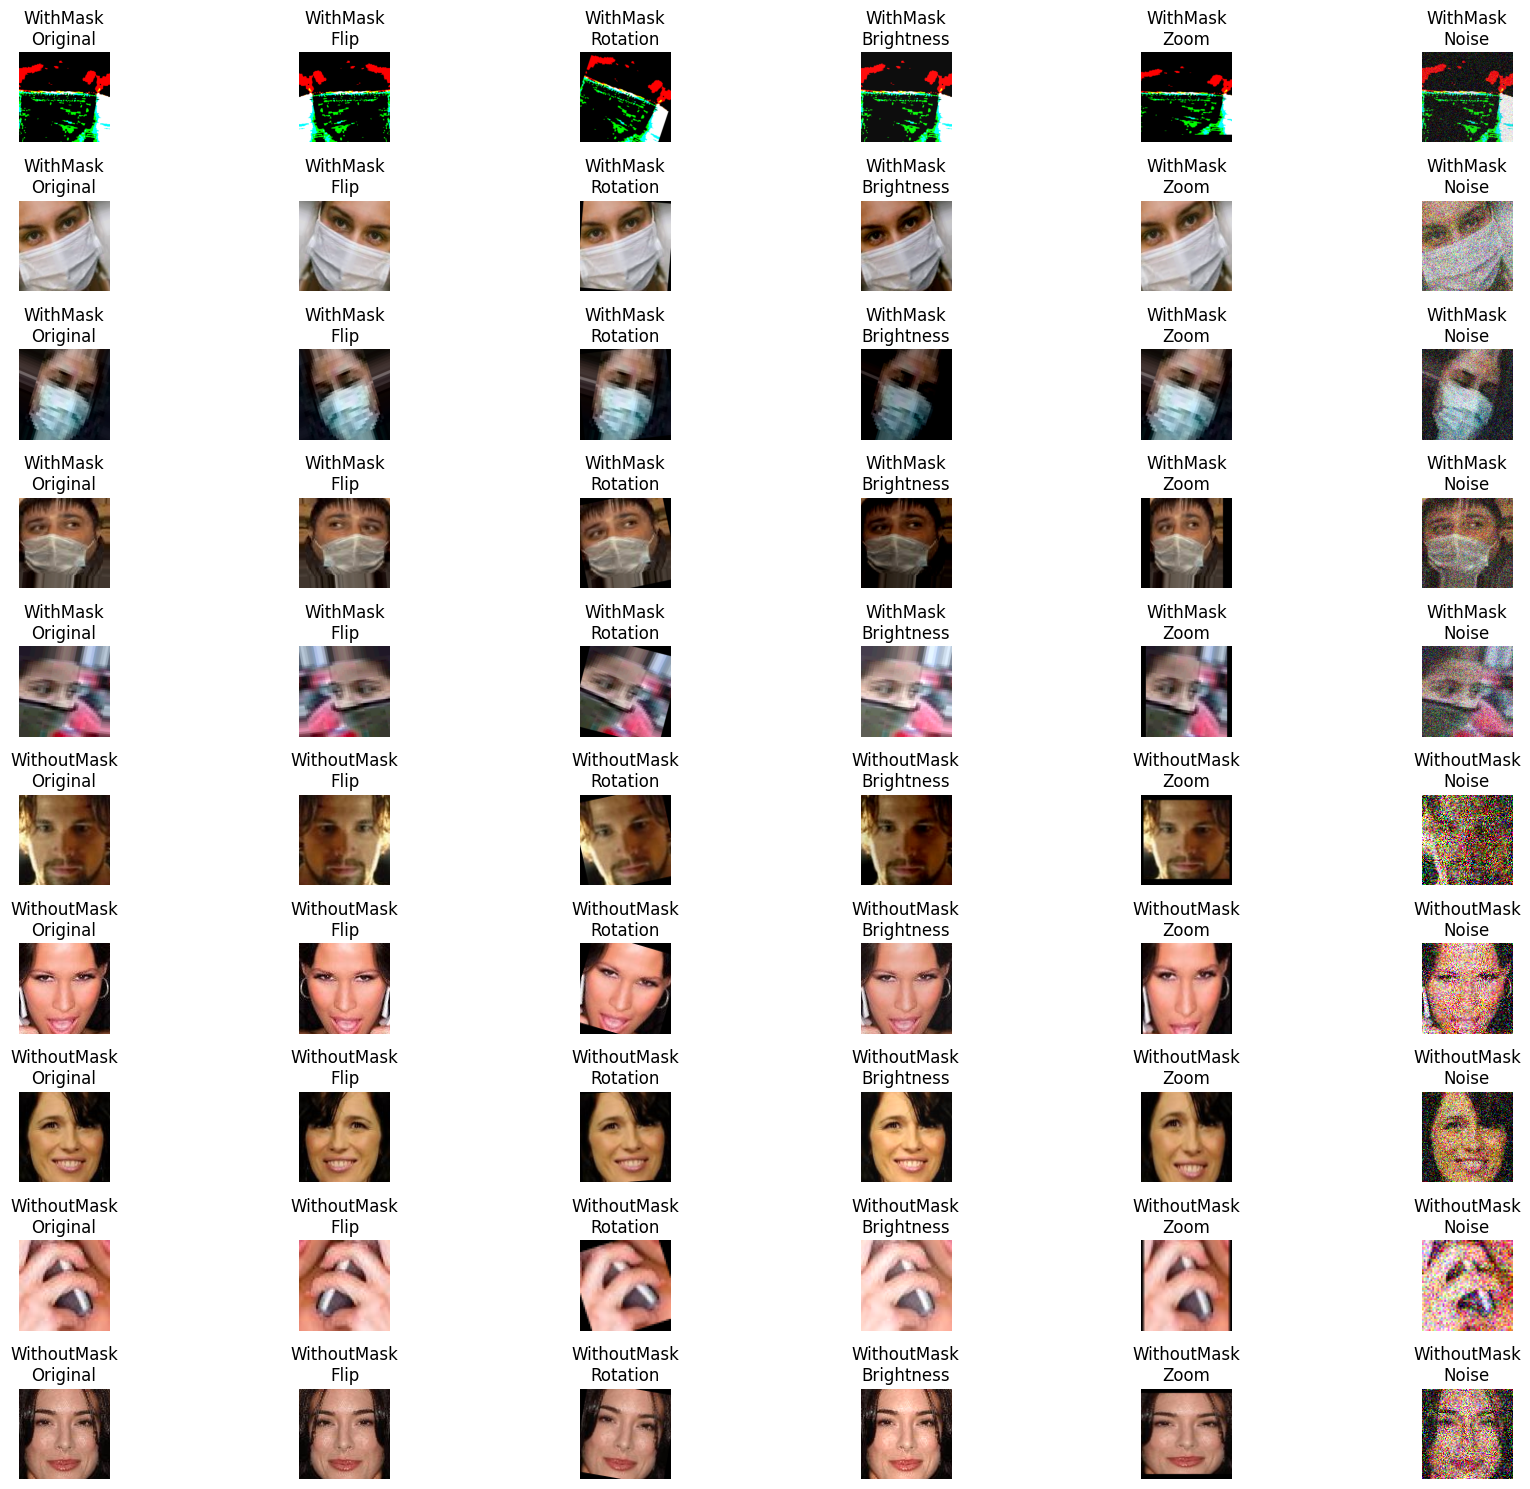

In [20]:
import os
import cv2
import matplotlib.pyplot as plt
import albumentations as A

with_mask_dir = os.path.join(train_dir, "WithMask")
without_mask_dir = os.path.join(train_dir, "WithoutMask")

def read_img(path):
    img = cv2.imread(path)
    if img is None:
        return None

    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img

augs = {
    "Original": None,
    "Flip": A.HorizontalFlip(p=1.0),
    "Rotation": A.Rotate(limit=20, p=1.0),
    "Brightness": A.RandomBrightnessContrast(p=1.0),
    "Zoom": A.Affine(scale=(0.8, 1.2), p=1.0),
    "Noise": A.GaussNoise(p=1.0),
}

with_images = os.listdir(with_mask_dir)[:5]
without_images = os.listdir(without_mask_dir)[:5]

all_images = [(with_mask_dir, img, "WithMask") for img in with_images] + \
             [(without_mask_dir, img, "WithoutMask") for img in without_images]

plt.figure(figsize=(18,15))

for i, (folder, img_name, label) in enumerate(all_images):
    path = os.path.join(folder, img_name)
    img = read_img(path)

    if img is None:
        continue

    col = 1

    for aug_name, aug in augs.items():

        if aug is None:
            out_img = img
        else:
            out_img = aug(image=img)["image"]

        plt.subplot(len(all_images), len(augs), i*len(augs)+col)
        plt.imshow(out_img)
        plt.title(f"{label}\n{aug_name}")
        plt.axis("off")

        col += 1

plt.tight_layout()
plt.show()

Validate Augmentation Quality(Face Still Visible,No Label Change(Label is Mask Or Non-Mask),Realistic Changes(Normal Changes To Photos))

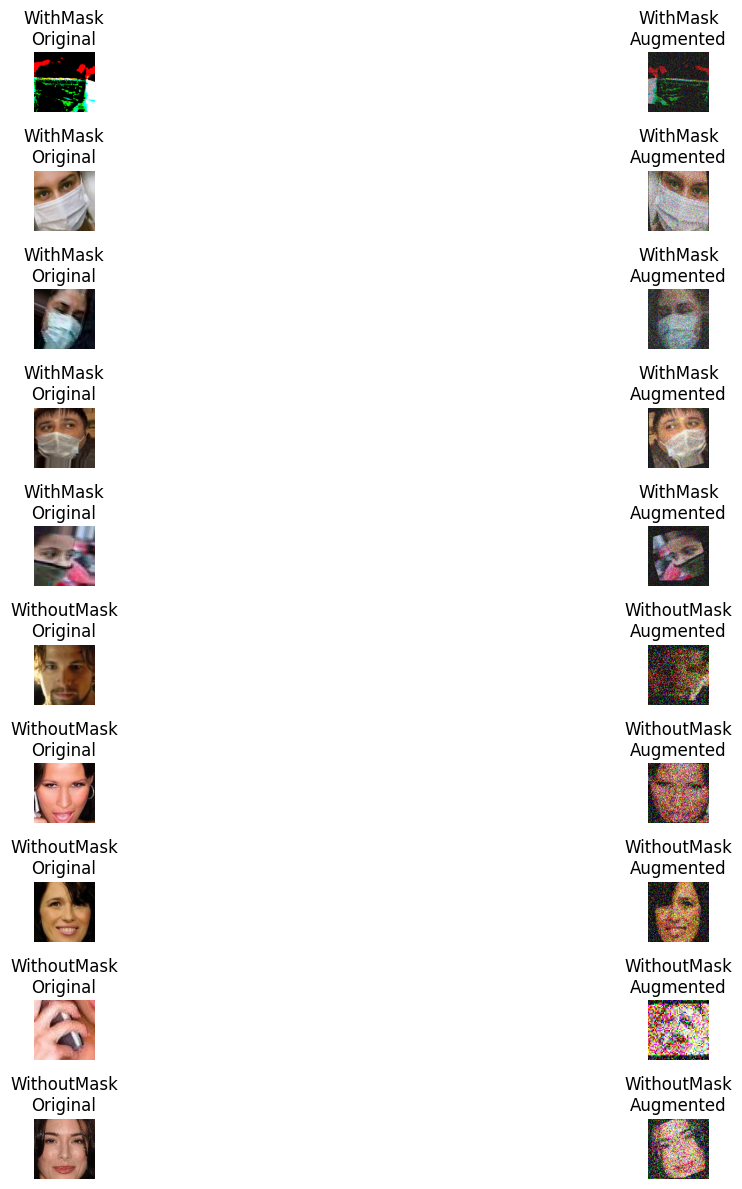

In [22]:
def read_img(path):
    img = cv2.imread(path)
    if img is None:
        return None

    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img

transform = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=20, p=1.0),
    A.RandomBrightnessContrast(p=1.0),
    A.Affine(scale=(0.8, 1.2), p=1.0),
    A.GaussNoise(p=1.0),
])

with_mask_dir = os.path.join(train_dir, "WithMask")
without_mask_dir = os.path.join(train_dir, "WithoutMask")

with_images = os.listdir(with_mask_dir)[:5]
without_images = os.listdir(without_mask_dir)[:5]

all_images = [(with_mask_dir, img, "WithMask") for img in with_images] + \
             [(without_mask_dir, img, "WithoutMask") for img in without_images]

plt.figure(figsize=(18,12))

for i, (folder, img_name, label) in enumerate(all_images):
    path = os.path.join(folder, img_name)
    img = read_img(path)

    if img is None:
        continue

    aug_img = transform(image=img)["image"]

    # Original
    plt.subplot(len(all_images), 2, i*2+1)
    plt.imshow(img)
    plt.title(f"{label}\nOriginal")
    plt.axis("off")

    # Augmented
    plt.subplot(len(all_images), 2, i*2+2)
    plt.imshow(aug_img)
    plt.title(f"{label}\nAugmented")
    plt.axis("off")

plt.tight_layout()
plt.show()

 Improving Dataset Diversity(Different lighting conditions
,Different face angles
,Slight distortions and noise)

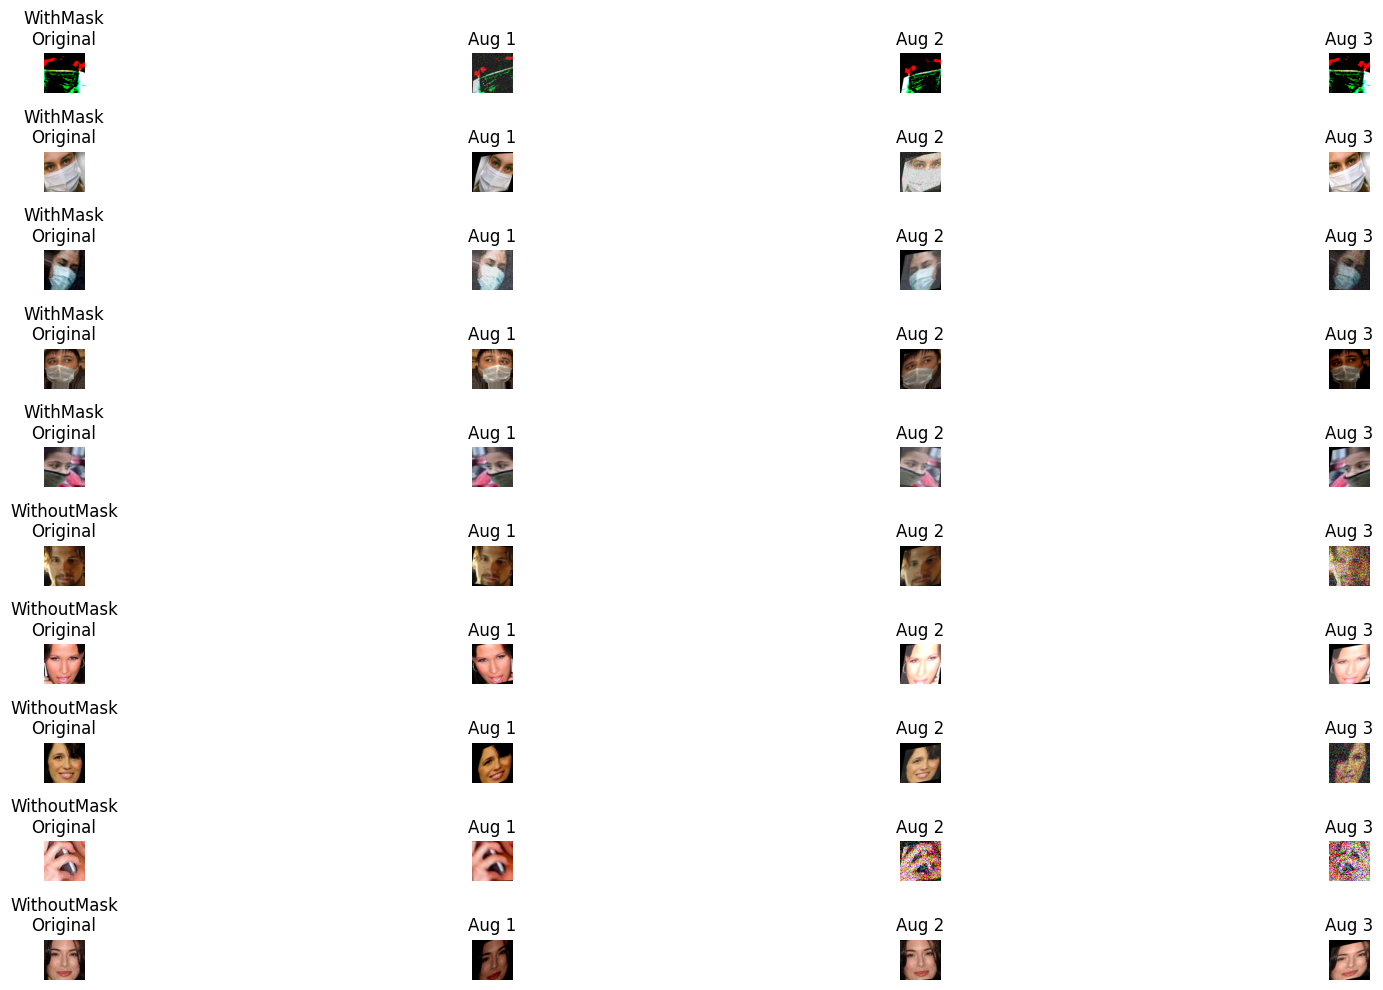

In [24]:
transform = A.Compose([
    A.HorizontalFlip(p=0.5),

    A.Rotate(limit=15, p=0.6),

    A.RandomBrightnessContrast(
        brightness_limit=0.3,
        contrast_limit=0.3,
        p=0.7
    ),

    A.Affine(
        scale=(0.85, 1.15),
        translate_percent=(0.05, 0.05),
        shear=10,
        p=0.6
    ),

    A.GaussNoise(p=0.4),

    A.MotionBlur(blur_limit=3, p=0.3)
])

def read_img(path):
    img = cv2.imread(path)
    if img is None:
        print("Problem In Photo:", path)
        return None

    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    return img

with_images = os.listdir(with_mask_dir)[:5]
without_images = os.listdir(without_mask_dir)[:5]

all_images = [(with_mask_dir, img, "WithMask") for img in with_images] + \
             [(without_mask_dir, img, "WithoutMask") for img in without_images]

num_augmented = 3

plt.figure(figsize=(20,10))

for i, (folder, img_name, label) in enumerate(all_images):
    path = os.path.join(folder, img_name)
    img = read_img(path)

    if img is None:
        continue

    plt.subplot(len(all_images), num_augmented+1, i*(num_augmented+1)+1)
    plt.imshow(img)
    plt.title(f"{label}\nOriginal")
    plt.axis("off")

    for j in range(num_augmented):
        aug_img = transform(image=img)["image"]

        plt.subplot(len(all_images), num_augmented+1, i*(num_augmented+1)+j+2)
        plt.imshow(aug_img)
        plt.title(f"Aug {j+1}")
        plt.axis("off")

plt.tight_layout()
plt.show()

## Augmentation Techniques Used

- Horizontal Flip: Simulates different face orientations.
- Rotation: Handles tilted faces.
- Brightness Adjustment: Simulates lighting changes.
- Zoom: Simulates distance variations.
- Noise: Improves robustness to image noise.